# Reinforcement Learning

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import gymnasium as gym
env = gym.make("CartPole-v1", render_mode='rgb_array', )
state = env.reset()
action = env.action_space.sample()  # take a random action
next_state, reward, terminated, truncated, info = env.step(action)
print("Next state:", next_state, "First reward:", reward, "Terminated:", terminated, "Truncated:", truncated,"info:", info)

In [ ]:
import numpy as np
import gymnasium as gym

# Create Environment
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")
state = env.reset()
action = env.action_space.sample()  # take a random action
next_state, reward, terminated, truncated, info = env.step(action)
print("Next state:", next_state, "First reward:", reward, "Terminated:", terminated, "Truncated:", truncated,"info:", info)

Next state: 4 First reward: 0.0 Terminated: False Truncated: False info: {'prob': 1.0}


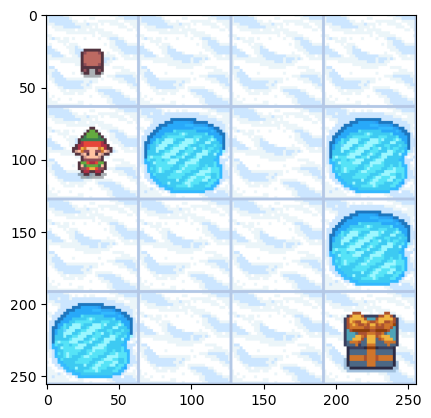

In [ ]:
import matplotlib.pyplot as plt
img = env.render()
plt.imshow(img)

In [ ]:
state_size = env.observation_space.n
action_size = env.action_space.n

In [ ]:
print(state_size,action_size)

16 4


In [ ]:
import numpy as np
import gym

env = gym.make("FrozenLake-v1", is_slippery=False)

# Initialize Q-table
Q = np.zeros([env.observation_space.n, env.action_space.n])
learning_rate = 0.8
discount_factor = 0.95
num_episodes = 2000

for _ in range(num_episodes):
    state = env.reset()
    state = state[0] if isinstance(state, tuple) else state
    print(state)
    done = False
    while not done:
        # Choose action
        action = np.argmax(Q[state]) if np.random.rand() > 0.1 else env.action_space.sample()

        # For newer gym versions (>=0.26)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Q-learning update
        Q[state, action] += learning_rate * (
            reward + discount_factor * np.max(Q[next_state]) - Q[state, action]
        )
        state = next_state

print("Trained Q-Table:")
print(Q)


0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [ ]:
import numpy as np
import gymnasium as gym
import pickle

# Create Environment
env = gym.make("FrozenLake-v1", is_slippery=False)
state_size = env.observation_space.n  # Number of states
action_size = env.action_space.n       # Number of actions

# Initialize Q-table
Q_table = np.zeros((state_size, action_size))

# Hyperparameters
alpha = 0.1         # Learning rate
gamma = 0.99        # Discount factor
epsilon = 1.0       # Exploration rate
epsilon_decay = 0.995  # Epsilon decay rate
epsilon_min = 0.01     # Minimum epsilon
episodes = 2000        # Number of training episodes

# Training loop
for episode in range(episodes):
    state = env.reset()[0]  # Reset environment and get initial state
    done = False

    while not done:
        # Choose action using epsilon-greedy strategy
        if np.random.rand() < epsilon:
            action = env.action_space.sample()  # Exploration
        else:
            action = np.argmax(Q_table[state])  # Exploitation

        # Take action and observe reward
        next_state, reward, terminated, truncated, _ = env.step(action)

        # Update Q-table using Bellman equation
        Q_table[state, action] += alpha * (
            reward + gamma * np.max(Q_table[next_state]) - Q_table[state, action]
        )

        state = next_state
        done = terminated or truncated

    # Decay epsilon
    epsilon = max(epsilon * epsilon_decay, epsilon_min)

# Save the Q-table
with open('q_table_frozenlake.pkl', 'wb') as f:
    pickle.dump(Q_table, f)

print("Training complete and model saved!")
env.close()

Training complete and model saved!


In [ ]:
np.save("frozenlake_q_table.npy", Q_table)
print("Q-table saved to frozenlake_q_table.npy")


Q-table saved to frozenlake_q_table.npy


In [ ]:
# Print the Q-table
print("Q-Table:")
print(Q_table)

Q-Table:
[[8.90055239e-01 7.21823817e-01 9.50990050e-01 9.07614848e-01]
 [8.97412142e-01 0.00000000e+00 9.60596010e-01 7.96172828e-01]
 [8.72338439e-01 9.70299000e-01 7.98641637e-01 8.76178933e-01]
 [9.24563702e-01 0.00000000e+00 6.40841098e-02 1.36713744e-02]
 [1.06108144e-01 8.76631706e-04 0.00000000e+00 8.80733649e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 9.80100000e-01 0.00000000e+00 8.97247751e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.84667716e-01 0.00000000e+00]
 [2.75633394e-02 0.00000000e+00 8.98113322e-01 0.00000000e+00]
 [6.83456761e-01 9.90000000e-01 0.00000000e+00 8.37341495e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.85167878e-02 8.69478798e-01 2.32100505e-02]
 [6.01075176e-01 8.81158956e-01 1.00000000e+00 9.32440931e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00

<Axes: >

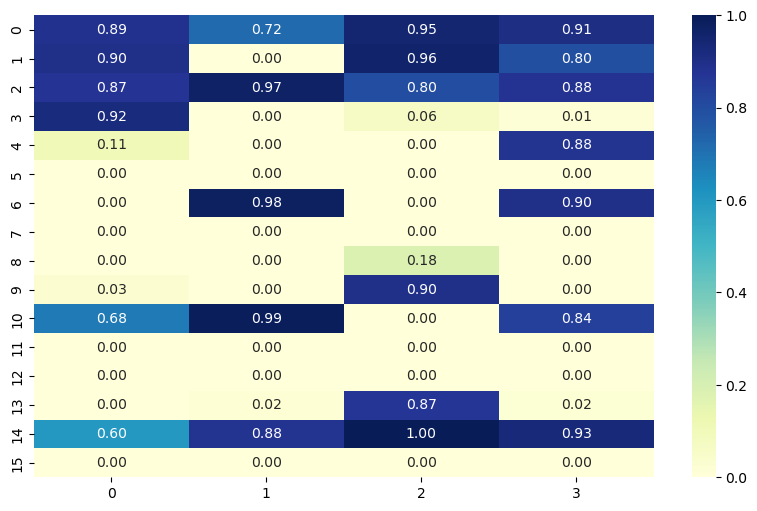

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a heatmap of the Q-values
plt.figure(figsize=(10, 6))
sns.heatmap(Q_table, annot=True, fmt=".2f", cmap="YlGnBu", cbar=True)
# plt.title("Q-Table Visualization for Frozen Lake")
# plt.xlabel("Actions")
# plt.ylabel("States")
# plt.xticks(np.arange(action_size) + 0.5, [f"Action {i}" for i in range(action_size)], rotation=0)
# plt.yticks(np.arange(state_size) + 0.5, [f"State {i}" for i in range(state_size)], rotation=0)
# plt.show()

In [ ]:
import gymnasium as gym
import numpy as np
import time

# Load trained Q-table
Q_table = np.load("frozenlake_q_table.npy")

# Create environment with rendering
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="human")
state, _ = env.reset()

done = False
total_reward = 0

while not done:
    time.sleep(0.5)  # Slow down to visualize
    action = np.argmax(Q_table[state])
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    total_reward += reward

env.close()
print(f"✅ Game over. Total reward: {total_reward}")


✅ Game over. Total reward: 1.0


In [ ]:
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="human")


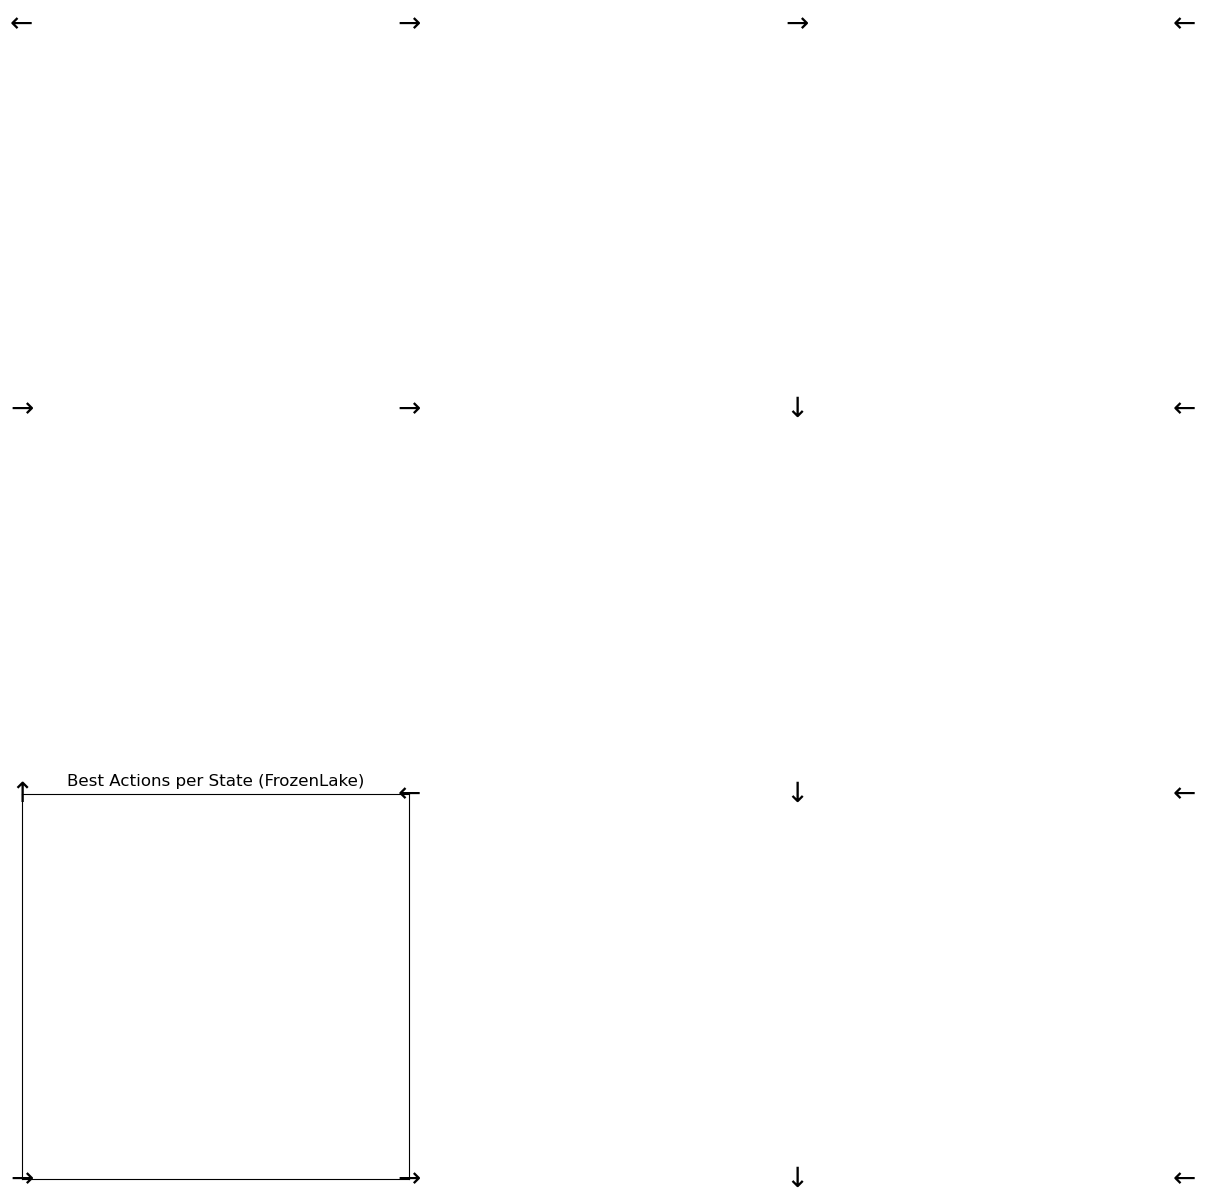

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Arrows for each action
arrows = ['←', '↓', '→', '↑']
best_actions = np.argmax(Q_table, axis=1).reshape((4, 4))  # for 4x4 FrozenLake

plt.figure(figsize=(5, 5))
for i in range(4):
    for j in range(4):
        action = best_actions[i, j]
        plt.text(j, i, arrows[action], ha='center', va='center', fontsize=20)

plt.xticks([])
plt.yticks([])
plt.grid(True)
plt.title("Best Actions per State (FrozenLake)")
plt.show()


In [ ]:
##  Bellman Equation

In [ ]:
import numpy as np
import gymnasium as gym

# Create and unwrap FrozenLake environment to access .P
env = gym.make("FrozenLake-v1", is_slippery=False)
env = env.unwrapped

state_size = env.observation_space.n
action_size = env.action_space.n

V = np.zeros(state_size)
gamma = 0.9
theta = 1e-4  # Stopping threshold

def one_step_lookahead(state, V):
    A = np.zeros(action_size)
    for a in range(action_size):
        for prob, next_state, reward, done in env.P[state][a]:
            A[a] += prob * (reward + gamma * V[next_state])
    return A

iteration = 0
while True:
    delta = 0
    for s in range(state_size):
        A = one_step_lookahead(s, V)
        best_action_value = np.max(A)
        delta = max(delta, np.abs(best_action_value - V[s]))
        V[s] = best_action_value
    iteration += 1
    if delta < theta:
        break

print(f"Final value function after {iteration} iterations:\n")
print(np.round(V.reshape(4, 4), 2))

Final value function after 7 iterations:

[[0.59 0.66 0.73 0.66]
 [0.66 0.   0.81 0.  ]
 [0.73 0.81 0.9  0.  ]
 [0.   0.9  1.   0.  ]]


In [ ]:
# Value iteration

In [ ]:
import gym
import numpy as np

env = gym.make("FrozenLake-v1", is_slippery=True)
nS, nA = env.observation_space.n, env.action_space.n
V = np.zeros(nS)
gamma = 0.99

for _ in range(1000):
    for s in range(nS):
        V[s] = max(sum(p * (r + gamma * V[s_]) for p, s_, r, _ in env.P[s][a]) for a in range(nA))

policy = np.zeros(nS, dtype=int)
for s in range(nS):
    policy[s] = np.argmax([sum(p * (r + gamma * V[s_]) for p, s_, r, _ in env.P[s][a]) for a in range(nA)])

def run(policy):
    s = env.reset()[0]
    total_reward = 0
    done = False
    while not done:
        s, r, done, _, _ = env.step(policy[s])
        total_reward += r
    print("Reward:", total_reward)

run(policy)


Reward: 1.0


In [ ]:
# Markov Decision Process

In [ ]:
import numpy as np
import gymnasium as gym

# Create Environment
env = gym.make("FrozenLake-v1", is_slippery=False)
state_size = env.observation_space.n
action_size = env.action_space.n

# Initialize value function and policy
V = np.zeros(state_size)
policy = np.zeros(state_size, dtype=int)

# Define hyperparameters
gamma = 0.99
theta = 1e-10

# Define transition and reward mapping
# For Frozen Lake, we can define the transitions manually based on the grid
transitions = {
    0: {0: (0, 0), 1: (4, 0), 2: (1, 0), 3: (0, 0)},
    1: {0: (1, 0), 1: (5, 0), 2: (2, 0), 3: (0, 0)},
    # Add all transitions for each state
}

# Value Iteration
while True:
    delta = 0
    for s in range(state_size):
        v = V[s]
        action_values = np.zeros(action_size)

        for a in range(action_size):
            next_state, reward = transitions[s][a]  # Get next state and reward

            action_values[a] = reward + gamma * V[next_state]

        V[s] = np.max(action_values)
        delta = max(delta, abs(v - V[s]))

    if delta < theta:
        break

# Derive policy
for s in range(state_size):
    action_values = np.zeros(action_size)
    for a in range(action_size):
        next_state, reward = transitions[s][a]
        action_values[a] = reward + gamma * V[next_state]
    policy[s] = np.argmax(action_values)

# Print the optimal policy and value function
print("Optimal Policy (0: Left, 1: Down, 2: Right, 3: Up):")
print(policy)
print("Value Function:")
print(V)

env.close()

In [ ]:
# DQN

In [ ]:
import gym
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import random

env = gym.make("FrozenLake-v1", is_slippery=True)
nS, nA = env.observation_space.n, env.action_space.n

def one_hot(state):
    return np.identity(nS)[state:state+1]

# Build simple Keras model
model = Sequential([
    Dense(128, activation='relu', input_shape=(nS,)),
    Dense(nA)
])
model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

gamma = 0.99
epsilon = 0.1

# Training
for episode in range(10000):
    s = env.reset()[0]
    done = False
    while not done:
        q_values = model.predict(one_hot(s), verbose=0)[0]
        if random.random() < epsilon:
            a = random.randint(0, nA-1)
        else:
            a = np.argmax(q_values)
        s_, r, done, _, _ = env.step(a)
        q_values_next = model.predict(one_hot(s_), verbose=0)[0]
        q_values[a] = r + gamma * np.max(q_values_next)
        model.fit(one_hot(s), np.array([q_values]), verbose=0)
        s = s_

# Evaluation
def run_dqn():
    s = env.reset()[0]
    done = False
    total_reward = 0
    while not done:
        a = np.argmax(model.predict(one_hot(s), verbose=0)[0])
        s, r, done, _, _ = env.step(a)
        total_reward += r
    print("DQN reward:", total_reward)

run_dqn()


In [ ]:
# Value Iteration (Dynamic Programming)

In [ ]:
import numpy as np
import gymnasium as gym

# Create Environment
env = gym.make("FrozenLake-v1", is_slippery=False)
state_size = env.observation_space.n
action_size = env.action_space.n

# Initialize value function and policy
V = np.zeros(state_size)
policy = np.zeros(state_size)

# Hyperparameters
gamma = 0.99
theta = 1e-10

while True:
    delta = 0
    for s in range(state_size):
        v = V[s]
        action_values = np.zeros(action_size)
        for a in range(action_size):
            next_state, reward, done, _, _ = env.step(a)  # Simulate next state
            action_values[a] += (1 / action_size) * (reward + gamma * V[next_state])
        V[s] = np.max(action_values)
        delta = max(delta, abs(v - V[s]))
    if delta < theta:
        break

# Derive policy
for s in range(state_size):
    action_values = np.zeros(action_size)
    for a in range(action_size):
        next_state, reward, done, _, _ = env.step(a)  # Simulate next state
        action_values[a] += (1 / action_size) * (reward + gamma * V[next_state])
    policy[s] = np.argmax(action_values)

print("Value Iteration completed!")

ResetNeeded: Cannot call env.step() before calling env.reset()

In [ ]:
# Deep Q Network

In [ ]:
import numpy as np
import gymnasium as gym
import tensorflow as tf
from collections import deque
import random

# Create Environment
env = gym.make("FrozenLake-v1", is_slippery=False)
state_size = env.observation_space.n
action_size = env.action_space.n

# Define DQN model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(24, input_dim=state_size, activation='relu'),
    tf.keras.layers.Dense(24, activation='relu'),
    tf.keras.layers.Dense(action_size, activation='linear')
])
model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(lr=0.001))

# Replay memory
memory = deque(maxlen=2000)
gamma = 0.95
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
episodes = 2000

for episode in range(episodes):
    state = env.reset()[0]
    done = False
    while not done:
        if np.random.rand() <= epsilon:
            action = env.action_space.sample()
        else:
            action_values = model.predict(np.identity(state_size)[state:state + 1])
            action = np.argmax(action_values[0])
        next_state, reward, terminated, truncated, _ = env.step(action)
        memory.append((state, action, reward, next_state, done))
        state = next_state
        done = terminated or truncated

        if len(memory) > 32:
            minibatch = random.sample(memory, 32)
            for s, a, r, ns, d in minibatch:
                target = r + (1 - d) * gamma * np.max(model.predict(np.identity(state_size)[ns:ns + 1]))
                target_f = model.predict(np.identity(state_size)[s:s + 1])
                target_f[0][a] = target
                model.fit(np.identity(state_size)[s:s + 1], target_f, epochs=1, verbose=0)

    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

print("DQN training completed!")

ValueError: Argument(s) not recognized: {'lr': 0.001}

In [ ]:
# Deep Q Network

In [ ]:
import gymnasium as gym
env = gym.make("CartPole-v1", render_mode='rgb_array')
state = env.reset()
action = env.action_space.sample()  # take a random action
next_state, reward, terminated, truncated, info = env.step(action)
print("Next state:", next_state, "First reward:", reward, "Terminated:", terminated, "Truncated:", truncated,"info:", info)  # Print the next state after taking the action
# print("First reward:", reward)  # Print the reward received for the action
# print("Terminated:", terminated)  # Print whether the episode has terminated (natural end)
# print("Truncated:", truncated)  # Print whether the episode was truncated (cut short)
# print("info:", info)  # Print additional information about the step

Next state: [ 0.03346913 -0.2367323  -0.00654088  0.30636957] First reward: 1.0 Terminated: False Truncated: False info: {}


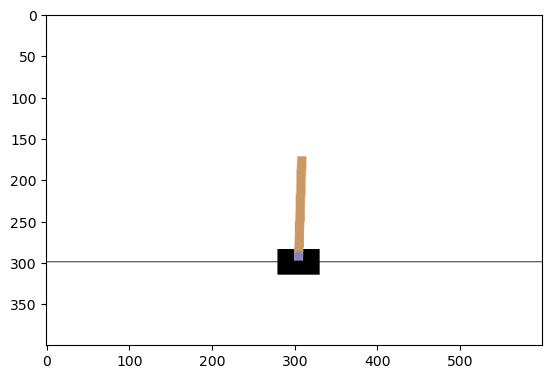

In [ ]:
import matplotlib.pyplot as plt
img = env.render()
plt.imshow(img)

In [ ]:
n_states = state.shape
n_actions = env.action_space.n  # Number of available actions
print("Number of actions:", n_actions)
print("Shape of state space:", n_states)
observation_space = env.observation_space
n_states = observation_space.shape[0]

Number of actions: 2
Shape of state space: (4,)


In [ ]:
# Q - Learning

In [ ]:
import numpy as np
import gymnasium as gym
import pickle

# Create Environment
env = gym.make("CartPole-v1")
n_actions = env.action_space.n

# Discretize the state space
n_states = (6, 12, 6, 12)  # Discretized state space dimensions
Q_table = np.zeros(n_states + (n_actions,))

# Hyperparameters
alpha = 0.1         # Learning rate
gamma = 0.99        # Discount factor
epsilon = 1.0       # Exploration rate
epsilon_decay = 0.995  # Epsilon decay rate
epsilon_min = 0.01     # Minimum epsilon
episodes = 2000        # Number of training episodes

def discretize(state):
    # Discretize the continuous state into discrete bins
    cart_pos, cart_vel, pole_angle, pole_vel = state

    # Define bins for each state variable
    cart_pos_bins = np.linspace(-2.4, 2.4, n_states[0] - 1)
    cart_vel_bins = np.linspace(-3.0, 3.0, n_states[1] - 1)
    pole_angle_bins = np.linspace(-0.209, 0.209, n_states[2] - 1)
    pole_vel_bins = np.linspace(-2.0, 2.0, n_states[3] - 1)

    # Get discrete indices
    cart_pos_index = np.digitize(cart_pos, cart_pos_bins)
    cart_vel_index = np.digitize(cart_vel, cart_vel_bins)
    pole_angle_index = np.digitize(pole_angle, pole_angle_bins)
    pole_vel_index = np.digitize(pole_vel, pole_vel_bins)

    return (cart_pos_index, cart_vel_index, pole_angle_index, pole_vel_index)

# Training loop
for episode in range(episodes):
    state = discretize(env.reset()[0])  # Reset and discretize the initial state
    done = False

    while not done:
        # Choose action using epsilon-greedy strategy
        if np.random.rand() < epsilon:
            action = env.action_space.sample()  # Exploration
        else:
            action = np.argmax(Q_table[state])  # Exploitation

        # Take action and observe reward
        next_state, reward, terminated, truncated, _ = env.step(action)
        next_state = discretize(next_state)  # Discretize next state

        # Update Q-table using Bellman equation
        Q_table[state][action] += alpha * (
            reward + gamma * np.max(Q_table[next_state]) - Q_table[state][action]
        )

        state = next_state
        done = terminated or truncated

    # Decay epsilon
    epsilon = max(epsilon * epsilon_decay, epsilon_min)

# Save the Q-table
with open('q_table_cartpole.pkl', 'wb') as f:
    pickle.dump(Q_table, f)

print("Training complete and model saved!")
env.close()

Training complete and model saved!


In [ ]:
# Policy Gradient (REINFORCE) with Keras

In [ ]:
import gymnasium as gym
import numpy as np
import tensorflow as tf

env = gym.make("CartPole-v1")
obs_size = env.observation_space.shape[0]
action_size = env.action_space.n

model = tf.keras.Sequential([
    tf.keras.layers.Dense(24, activation='relu', input_shape=(obs_size,)),
    tf.keras.layers.Dense(action_size, activation='softmax')
])
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

def discount_rewards(rewards, gamma=0.99):
    discounted = np.zeros_like(rewards, dtype=np.float32)
    running_add = 0
    for t in reversed(range(len(rewards))):
        running_add = running_add * gamma + rewards[t]
        discounted[t] = running_add
    return discounted

for episode in range(1000):
    state, _ = env.reset()
    states, actions, rewards = [], [], []
    done = False

    while not done:
        state = state.reshape(1, -1)
        probs = model(state).numpy()[0]
        action = np.random.choice(action_size, p=probs)

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        states.append(state[0])
        actions.append(action)
        rewards.append(reward)

        state = next_state

    # Convert to arrays
    states = np.vstack(states)
    actions = np.array(actions)
    discounted_rewards = discount_rewards(rewards)

    with tf.GradientTape() as tape:
        logits = model(states, training=True)
        action_masks = tf.one_hot(actions, action_size)
        log_probs = tf.reduce_sum(action_masks * tf.math.log(logits + 1e-8), axis=1)
        loss = -tf.reduce_mean(log_probs * discounted_rewards)

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    if episode % 100 == 0:
        print(f"Episode {episode}, total reward: {np.sum(rewards)}")


Episode 0, total reward: 19.0
Episode 100, total reward: 61.0
Episode 200, total reward: 90.0
Episode 300, total reward: 106.0



KeyboardInterrupt



## Q Learning

In [ ]:
import numpy as np
import gymnasium as gym

# Create Environment
env = gym.make("FrozenLake-v1", is_slippery=False)
state_size = env.observation_space.n
action_size = env.action_space.n

Q_table = np.zeros((state_size, action_size))

alpha = 0.1         # Learning rate: how fast the agent learns new info
                   # Range: 0 < alpha ≤ 1 (typical: 0.01 to 0.3)
                   # Too low = slow learning, too high = unstable

gamma = 0.99        # Discount factor: how much future rewards are valued
                   # Range: 0 ≤ gamma ≤ 1 (typical: 0.9 to 0.99)
                   # 0 = only care about now, 1 = care about long-term rewards

epsilon = 1.0       # Exploration rate: chance of trying random actions
                   # Range: 0 ≤ epsilon ≤ 1 (start high to explore)
                   # High = lots of exploring, low = always play it safe

epsilon_decay = 0.995  # Controls how quickly exploration decreases over time
                       # Range: 0 < decay < 1 (typical: 0.99 to 0.999)
                       # Closer to 1 = slower decay = explore longer

epsilon_min = 0.01     # Smallest value epsilon can reach (still explores a little)
                       # Range: 0 ≤ epsilon_min ≤ 1 (typical: 0.01 to 0.1)

episodes = 200        # Number of training episodes (games)
                       # More episodes = better learning, but longer time

for episode in range(episodes):
    state = env.reset()[0]
    done = False

    while not done:
        # Choose action using epsilon-greedy strategy
        if np.random.rand() < epsilon:
            action = np.random.choice(action_size)  # Exploration
        else:
            action = np.argmax(Q_table[state])  # Exploitation

        # Take action and observe reward
        next_state, reward, done, _, _ = env.step(action)

        # Update Q-table using Bellman equation
        Q_table[state, action] = Q_table[state, action] + alpha * (
            reward + gamma * np.max(Q_table[next_state]) - Q_table[state, action]
        )

        state = next_state

    # Decay epsilon to reduce exploration over time
    epsilon = max(epsilon * epsilon_decay, epsilon_min)

print("Training complete!")


Training complete!
